In [218]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import precision_recall_fscore_support, confusion_matrix

In [219]:
# =========================
# 基本設定
# =========================

root = "results_loso/1214_3"
#root = "results_loso/0430_ratio010"
target_seed = "seed0"
target_session = "S0100"

model_names = {
    "CNN": "T1_cnn",
    "PreCNN": "T2_precnn",
    "CNN-T": "T4_cnn-transformer",
    "PreCNN-T": "T5_precnn-transformer",
}

label_names = [
    "Assemble Box",
    "Attach Box Label",
    "Attach Shipping Label",
    "Close Box",
    "Fill out Order",
    "Insert Items",
    "Picking",
    "Put on Back Table",
    "Relocate Item Label",
    "Scan Label",
]

num_classes = len(label_names)
stride_sec = 4

In [220]:
def load_model_outputs(root, model_dir, target_seed="seed0", target_session="S0100"):
    base_dir = os.path.join(root, target_seed, model_dir, target_session)

    records = []
    y_true_all = []
    y_pred_all = []

    for fname in sorted(os.listdir(base_dir)):
        if not fname.endswith(".json"):
            continue

        user = fname.replace(".json", "")
        path = os.path.join(base_dir, fname)

        with open(path, "r") as f:
            r = json.load(f)

        y_true = np.array(r["y_true"])
        y_pred = np.array(r["y_pred"])

        records.append({
            "user": user,
            "y_true": y_true,
            "y_pred": y_pred,
            "path": path,
        })

        y_true_all.append(y_true)
        y_pred_all.append(y_pred)

    return {
        "records": records,
        "y_true": np.concatenate(y_true_all),
        "y_pred": np.concatenate(y_pred_all),
    }

In [221]:
outputs = {}

for disp_name, model_dir in model_names.items():
    outputs[disp_name] = load_model_outputs(
        root=root,
        model_dir=model_dir,
        target_seed=target_seed,
        target_session=target_session,
    )

    print(disp_name, len(outputs[disp_name]["y_true"]))

CNN 9502
PreCNN 9502
CNN-T 9372
PreCNN-T 9372


In [222]:
def compute_per_class_metrics(y_true, y_pred, num_classes, label_names):
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=np.arange(num_classes),
        zero_division=0,
    )

    return pd.DataFrame({
        "label": np.arange(num_classes),
        "label_name": label_names,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "support": support,
    })

In [223]:
metric_dfs = []

for model_name, out in outputs.items():
    df = compute_per_class_metrics(
        out["y_true"],
        out["y_pred"],
        num_classes=num_classes,
        label_names=label_names,
    )
    df["model"] = model_name
    metric_dfs.append(df)

df_metrics = pd.concat(metric_dfs, ignore_index=True)
display(df_metrics)

,label,label_name,precision,recall,f1,support,model
0,0,Assemble Box,0.527168,0.570000,0.547748,1600,CNN
1,1,Attach Box Label,0.434535,0.553140,0.486716,414,CNN
2,2,Attach Shipping Label,0.710125,0.735632,0.722653,696,CNN
3,3,Close Box,0.479821,0.415131,0.445138,1031,CNN
4,4,Fill out Order,0.435924,0.533419,0.479769,778,CNN
5,5,Insert Items,0.644423,0.750277,0.693333,901,CNN
6,6,Picking,0.719512,0.672539,0.695233,965,CNN
7,7,Put on Back Table,0.648770,0.721393,0.683157,402,CNN
8,8,Relocate Item Label,0.598282,0.448498,0.512674,1398,CNN
9,9,Scan Label,0.642626,0.602126,0.621717,1317,CNN


In [224]:
df_metrics_clean = df_metrics.copy()

df_metrics_clean = df_metrics_clean[
    ["label", "label_name", "model", "f1", "support"]
]

In [225]:
def extract_runs(labels):
    labels = np.asarray(labels)

    if len(labels) == 0:
        return []

    runs = []
    current = labels[0]
    length = 1

    for x in labels[1:]:
        if x == current:
            length += 1
        else:
            runs.append((int(current), length))
            current = x
            length = 1

    runs.append((int(current), length))
    return runs

def collect_duration_stats(outputs_one_model, stride_sec=4):
    rows = []

    for rec in outputs_one_model["records"]:
        user = rec["user"]
        y_true = rec["y_true"]

        for label, length in extract_runs(y_true):
            rows.append({
                "user": user,
                "label": label,
                "duration_sec": length * stride_sec,
            })

    df_dur = pd.DataFrame(rows)

    df_sum = (
        df_dur.groupby("label")["duration_sec"]
        .agg(["count", "mean", "median", "std", "min", "max"])
        .reset_index()
    )

    return df_dur, df_sum

In [226]:
import pandas as pd
import os

def load_annotation_duration(user, session, base_dir="../openpack_subset"):
    path = f"{base_dir}/{user}/annotation/openpack-operations/{session}.csv"

    df = pd.read_csv(path)

    df["start"] = pd.to_datetime(df["start"], format="mixed")
    df["end"]   = pd.to_datetime(df["end"], format="mixed")

    df["duration_sec"] = (df["end"] - df["start"]).dt.total_seconds()

    return df[["operation", "duration_sec"]]

def collect_true_durations(users, session):
    rows = []

    for user in users:
        try:
            df = load_annotation_duration(user, session)
        except:
            continue

        for _, r in df.iterrows():
            rows.append({
                "user": user,
                "label_name": r["operation"],
                "duration_sec": r["duration_sec"],
            })

    return pd.DataFrame(rows)

In [227]:
users = ["U0101", "U0102", "U0103", "U0104", "U0105",
         "U0106", "U0107", "U0108", "U0109", "U0110",
         "U0111", "U0201", "U0206", "U0207", "U0208",
         "U0209"]

df_true = collect_true_durations(users, "S0100")

df_true_stats = (
    df_true.groupby("label_name")["duration_sec"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .reset_index()
)

display(df_true_stats)

,label_name,count,mean,median,std,min,max
0,Assemble Box,319,19.008527,18.411,6.396827,2.764,55.386
1,Attach Box Label,310,5.212703,4.863,1.802962,1.425,11.836
2,Attach Shipping Label,311,8.524605,8.337,2.406390,0.255,24.732
3,Close Box,314,12.320360,12.085,3.551590,1.893,27.408
4,Fill out Order,321,9.319916,8.301,4.280312,0.927,32.074
5,Insert Items,319,10.753138,9.583,5.672381,1.871,48.753
6,Null,27,5.721852,4.217,3.868218,1.907,15.049
7,Picking,310,11.709206,10.476,5.644220,1.648,58.794
8,Put on Back Table,276,5.615598,5.707,1.490385,0.488,12.589
9,Relocate Item Label,313,17.044569,12.599,11.918053,2.851,92.019


In [228]:
label_map = {name: i for i, name in enumerate(label_names)}

df_true_stats["label"] = df_true_stats["label_name"].map(label_map)

In [229]:
# =========================
# df_metrics_clean 以降
# =========================

# 1. F1をモデルごとに横持ち化
df_wide = df_metrics_clean.pivot(
    index=["label", "label_name"],
    columns="model",
    values="f1"
).reset_index()

# columns名を通常の文字列に戻す
df_wide.columns.name = None

# 2. supportをlabelごとにまとめる
# ※ モデル間でsupportが微妙に違う場合があるので平均を使う
support_df = (
    df_metrics_clean
    .groupby("label", as_index=False)["support"]
    .mean()
    .rename(columns={"support": "support_mean"})
)


# 4. merge
df_wide = df_wide.merge(
    df_true_stats,
    on="label",
    suffixes=("", "_true")
)

# 5. 差分を計算
# 表現学習の効果
df_wide["delta_CNN_to_PreCNN"] = df_wide["PreCNN"] - df_wide["CNN"]

# 文脈（Transformer）の効果
df_wide["delta_PreCNN_to_PreCNNT"] = df_wide["PreCNN-T"] - df_wide["PreCNN"]

# 全体改善（参考）
df_wide["delta_CNN_to_PreCNNT"] = df_wide["PreCNN-T"] - df_wide["CNN"]

# 6. 確認
print("label count:")
print(df_wide["label"].value_counts())

display(
    df_wide.sort_values("delta_CNN_to_PreCNN", ascending=False)[
        ["label_name", "median", "CNN", "PreCNN", "delta_CNN_to_PreCNN"]
    ]
)
display(
    df_wide.sort_values("delta_PreCNN_to_PreCNNT", ascending=False)[
        ["label_name", "median", "PreCNN", "PreCNN-T", "delta_PreCNN_to_PreCNNT"]
    ]
)

label count:
label
0    1
1    1
2    1
3    1
4    1
5    1
6    1
7    1
8    1
9    1
Name: count, dtype: int64


,label_name,median,CNN,PreCNN,delta_CNN_to_PreCNN
4,Fill out Order,8.301,0.479769,0.517906,0.038138
3,Close Box,12.085,0.445138,0.479439,0.034301
9,Scan Label,14.068,0.621717,0.643368,0.021651
6,Picking,10.476,0.695233,0.688828,-0.006405
0,Assemble Box,18.411,0.547748,0.536903,-0.010845
7,Put on Back Table,5.707,0.683157,0.655702,-0.027455
8,Relocate Item Label,12.599,0.512674,0.481689,-0.030985
5,Insert Items,9.583,0.693333,0.643700,-0.049633
2,Attach Shipping Label,8.337,0.722653,0.670300,-0.052354
1,Attach Box Label,4.863,0.486716,0.420863,-0.065853


,label_name,median,PreCNN,PreCNN-T,delta_PreCNN_to_PreCNNT
8,Relocate Item Label,12.599,0.481689,0.901203,0.419514
3,Close Box,12.085,0.479439,0.894260,0.414821
0,Assemble Box,18.411,0.536903,0.908976,0.372073
4,Fill out Order,8.301,0.517906,0.864569,0.346663
1,Attach Box Label,4.863,0.420863,0.758130,0.337267
9,Scan Label,14.068,0.643368,0.877052,0.233685
2,Attach Shipping Label,8.337,0.670300,0.901019,0.230719
7,Put on Back Table,5.707,0.655702,0.869136,0.213434
5,Insert Items,9.583,0.643700,0.852910,0.209210
6,Picking,10.476,0.688828,0.869377,0.180548


In [230]:
print(df_metrics_clean["model"].unique())
print(df_wide.columns)

['CNN' 'PreCNN' 'CNN-T' 'PreCNN-T']
Index(['label', 'label_name', 'CNN', 'CNN-T', 'PreCNN', 'PreCNN-T',
       'label_name_true', 'count', 'mean', 'median', 'std', 'min', 'max',
       'delta_CNN_to_PreCNN', 'delta_PreCNN_to_PreCNNT',
       'delta_CNN_to_PreCNNT'],
      dtype='object')


In [274]:
# PreCNN-Tを主分析対象にする
df_plot = df_wide[[
    "label",
    "label_name",
    "count",
    "mean",
    "median",
    "std",
    "min",
    "max",
    "CNN",
    "PreCNN",
    "CNN-T",
    "PreCNN-T",
]].copy()

df_plot = df_plot.rename(columns={
    "PreCNN": "precnn_f1",
    "PreCNN-T": "precnn-t_f1"
})

display(df_plot.sort_values("duration_sec_mean"))

KeyError: 'duration_sec_mean'

In [ ]:
import pandas as pd

# ===== 必要な列だけ抽出 =====
df_table = df_plot[[
    "label_name",
    "mean",
    "std",
    "f1"
]].copy()

# ===== 丸め（小数点2桁）=====
df_table["mean"] = df_table["mean"].round(1)
df_table["std"] = df_table["std"].round(1)
df_table["f1"] = df_table["f1"].round(2)

# ===== 表示用フォーマット =====
df_table["Duration [sec]"] = df_table.apply(
    lambda r: f'{r["mean"]} ± {r["std"]}', axis=1
)

df_table["F1-score"] = df_table["f1"].apply(lambda x: f"{x:.2f}")

# ===== 最終テーブル =====
df_final = df_table[[
    "label_name",
    "Duration [sec]",
    "F1-score"
]].sort_values("F1-score", ascending=False)

# ===== print =====
print(df_final.to_string(index=False))

           label_name Duration [sec] F1-score
         Assemble Box     19.0 ± 6.4     0.91
Attach Shipping Label      8.5 ± 2.4     0.90
  Relocate Item Label    17.0 ± 11.9     0.90
            Close Box     12.3 ± 3.6     0.89
           Scan Label     15.3 ± 9.0     0.88
              Picking     11.7 ± 5.6     0.87
    Put on Back Table      5.6 ± 1.5     0.87
       Fill out Order      9.3 ± 4.3     0.86
         Insert Items     10.8 ± 5.7     0.85
     Attach Box Label      5.2 ± 1.8     0.76


In [232]:
import pandas as pd

models = ["CNN", "PreCNN", "CNN-T", "PreCNN-T"]
features = ["mean", "median", "std", "min", "max"]

corr_rows = []

for model in models:
    for feat in features:
        corr = df_wide[feat].corr(df_wide[model])
        corr_rows.append({
            "model": model,
            "feature": feat,
            "corr": corr
        })

df_corr = pd.DataFrame(corr_rows)
display(df_corr)

,model,feature,corr
0,CNN,mean,-0.195046
1,CNN,median,-0.161014
2,CNN,std,-0.120718
3,CNN,min,-0.438921
4,CNN,max,0.067149
5,PreCNN,mean,-0.078941
6,PreCNN,median,-0.019777
7,PreCNN,std,-0.056317
8,PreCNN,min,-0.478288
9,PreCNN,max,0.190403


In [233]:
df_corr_pivot = df_corr.pivot(
    index="model",
    columns="feature",
    values="corr"
)

display(df_corr_pivot)

feature,max,mean,median,min,std
model,,,,,
CNN,0.067149,-0.195046,-0.161014,-0.438921,-0.120718
CNN-T,0.333293,0.464939,0.462808,-0.061988,0.353620
PreCNN,0.190403,-0.078941,-0.019777,-0.478288,-0.056317
PreCNN-T,0.335397,0.642029,0.653847,0.185068,0.416276


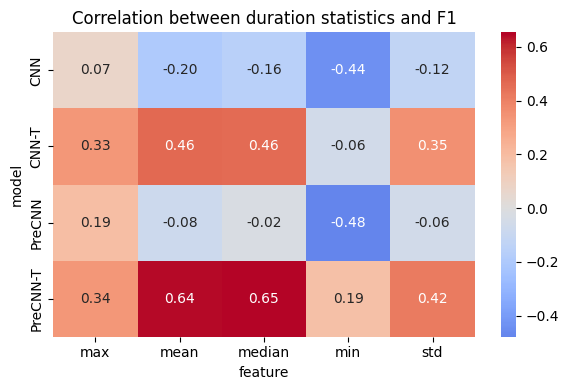

In [234]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.heatmap(
    df_corr_pivot,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)

plt.title("Correlation between duration statistics and F1")
plt.tight_layout()
plt.show()

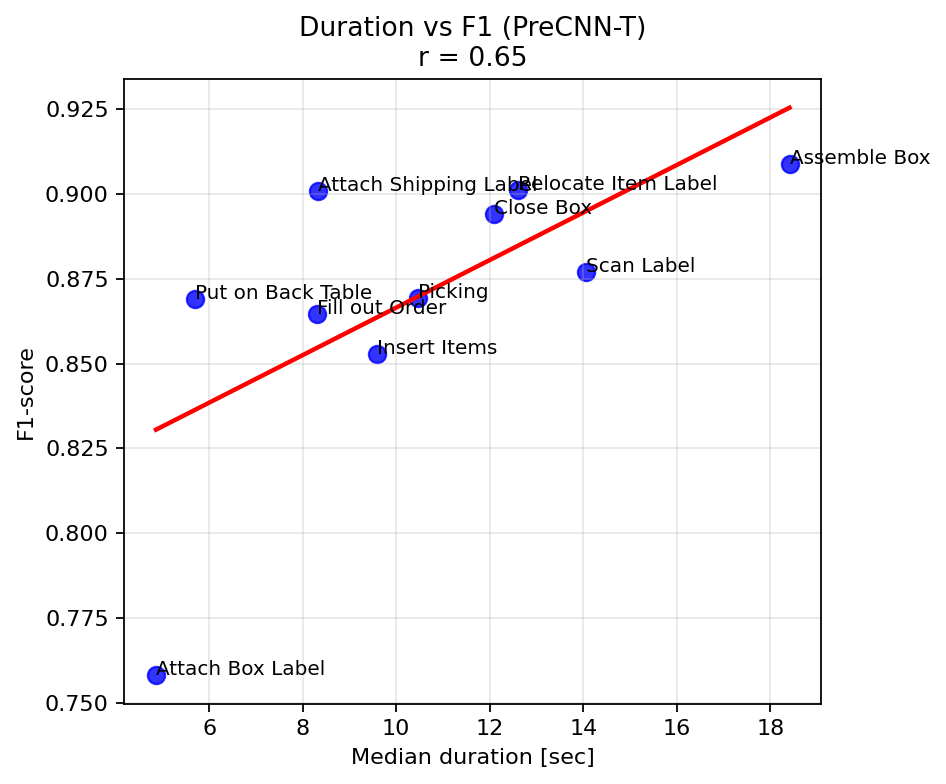

In [235]:
import numpy as np
import matplotlib.pyplot as plt

x = df_wide["median"]
y = df_wide["PreCNN-T"]

# 回帰直線
coef = np.polyfit(x, y, 1)
x_line = np.linspace(x.min(), x.max(), 100)
y_line = coef[0] * x_line + coef[1]

# 相関
corr = np.corrcoef(x, y)[0,1]

plt.figure(figsize=(6,5), dpi=160)

plt.scatter(x, y, s=60, color="blue", alpha=0.8)
plt.plot(x_line, y_line, color="red", linewidth=2)

for _, r in df_wide.iterrows():
    plt.text(r["median"], r["PreCNN-T"], r["label_name"], fontsize=9)

plt.xlabel("Median duration [sec]")
plt.ylabel("F1-score")
plt.title(f"Duration vs F1 (PreCNN-T)\nr = {corr:.2f}")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

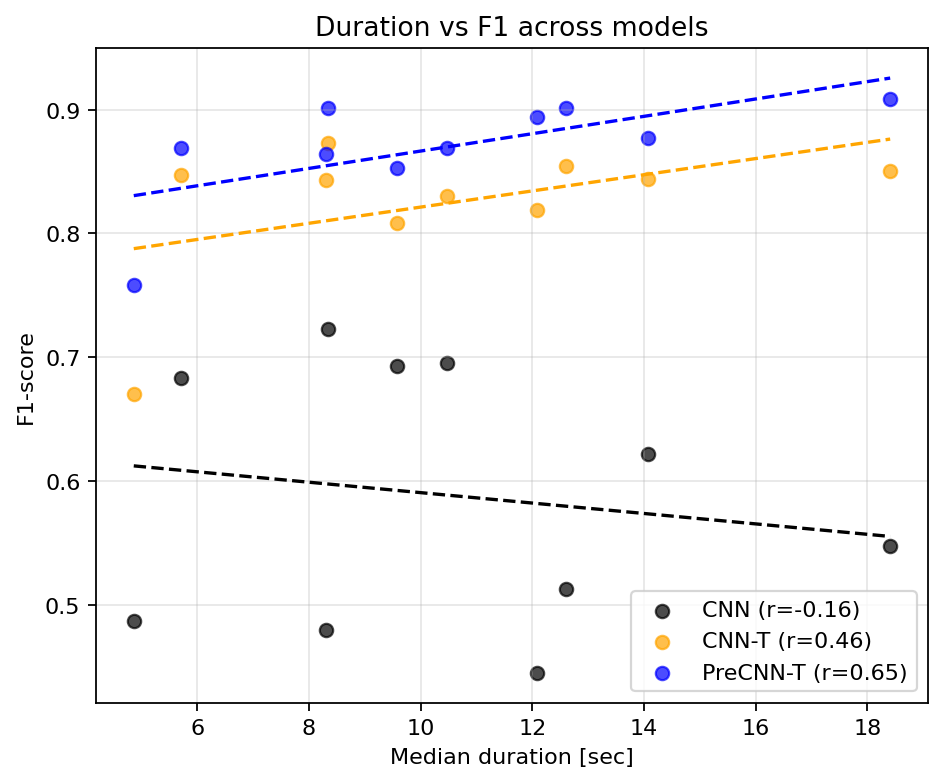

In [236]:
plt.figure(figsize=(6,5), dpi=160)

colors = {
    "CNN": "black",
    "CNN-T": "orange",
    "PreCNN-T": "blue"
}

for model in ["CNN", "CNN-T", "PreCNN-T"]:
    x = df_wide["median"]
    y = df_wide[model]

    coef = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = coef[0] * x_line + coef[1]

    corr = np.corrcoef(x, y)[0,1]

    plt.scatter(x, y, color=colors[model], label=f"{model} (r={corr:.2f})", alpha=0.7)
    plt.plot(x_line, y_line, color=colors[model], linestyle="--")

plt.xlabel("Median duration [sec]")
plt.ylabel("F1-score")
plt.title("Duration vs F1 across models")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

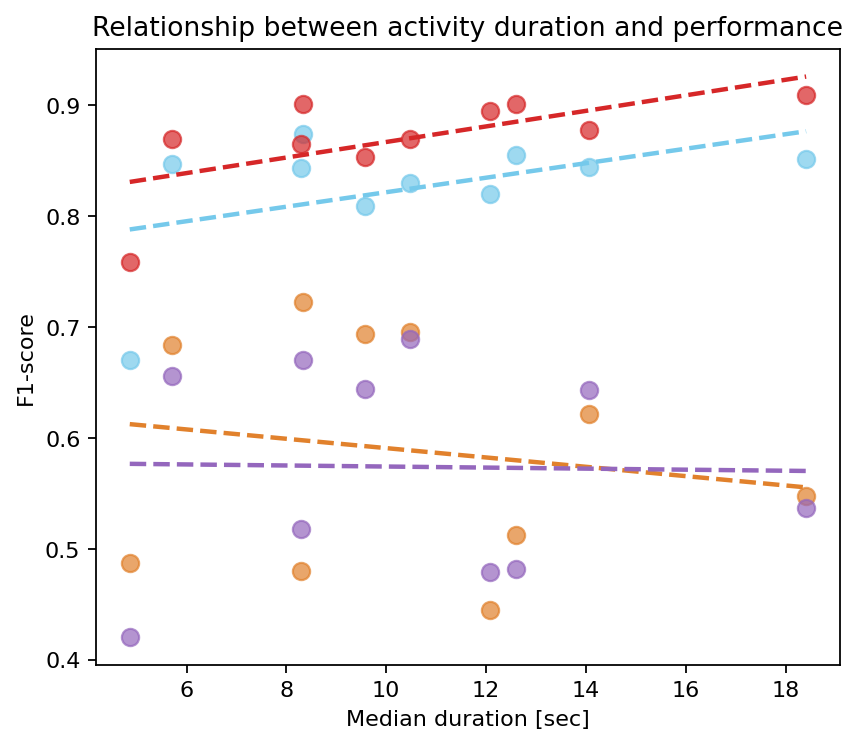

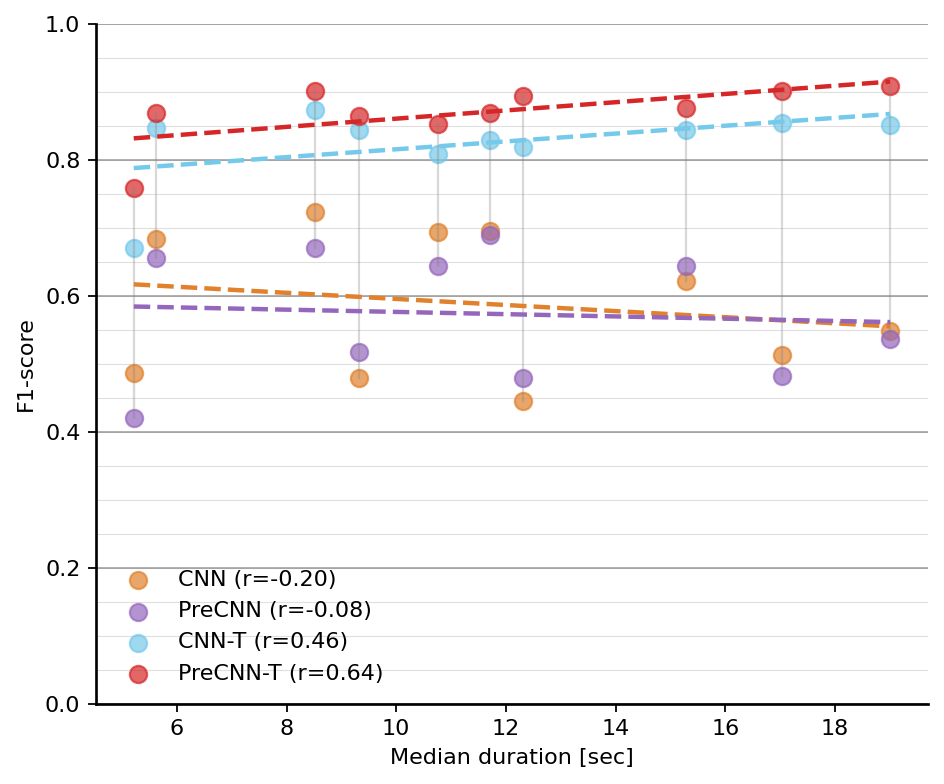

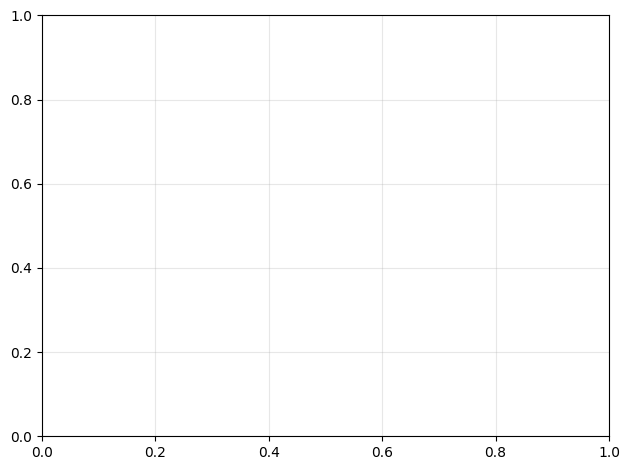

In [237]:
plt.figure(figsize=(6,5), dpi=160)

models = ["CNN", "PreCNN", "CNN-T", "PreCNN-T"]

colors = {
    "CNN": "#E1812C", #"black",
    "PreCNN": "#9467bd", #"red",
    "CNN-T": "#75c9eb", #"orange",
    "PreCNN-T": "#d62728" #"blue"
}

for model in models:
    x = df_wide["median"]
    y = df_wide[model]

    # 回帰直線
    coef = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = coef[0] * x_line + coef[1]

    # 相関
    corr = np.corrcoef(x, y)[0,1]

    plt.scatter(
        x, y,
        color=colors[model],
        alpha=0.7,
        s=60,
        label=f"{model} (r={corr:.2f})"
    )

    plt.plot(
        x_line, y_line,
        color=colors[model],
        linestyle="--",
        linewidth=2
    )

# ラベル（重なり防止で少し右に）
for _, r in df_wide.iterrows():
    #plt.text(r["median"] + 0.3, r["PreCNN-T"], r["label_name"], fontsize=9)
    pass

plt.xlabel("Median duration [sec]")
plt.ylabel("F1-score")
plt.title("Relationship between activity duration and performance")

plt.figure(figsize=(6,5), dpi=160)
ax = plt.gca()

models = ["CNN", "PreCNN", "CNN-T", "PreCNN-T"]

colors = {
    "CNN": "#E1812C",
    "PreCNN": "#9467bd",
    "CNN-T": "#75c9eb",
    "PreCNN-T": "#d62728"
}

# ===== 背景：横線のみ =====
for y in np.arange(0, 1.01, 0.2):
    ax.axhline(y, color="gray", lw=0.9, alpha=0.6, zorder=0)
for y in np.arange(0, 1.01, 0.05):
    ax.axhline(y, color="gray", lw=0.5, alpha=0.25, zorder=0)

# ===== 枠線：左と下だけ =====
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.2)
ax.spines["bottom"].set_linewidth(1.2)

# ===== プロット =====
for model in models:
    x = df_wide["mean"]
    y = df_wide[model]

    coef = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = coef[0] * x_line + coef[1]

    corr = np.corrcoef(x, y)[0,1]

    ax.scatter(
        x, y,
        color=colors[model],
        alpha=0.7,
        s=60,
        label=f"{model} (r={corr:.2f})"
    )

    ax.plot(
        x_line, y_line,
        color=colors[model],
        linestyle="--",
        linewidth=2
    )


# ===== 同一作業を縦に接続 =====
for i in range(len(df_wide)):
    x_val = df_wide["mean"].iloc[i]
    ys = [df_wide[m].iloc[i] for m in models]

    ax.plot(
        [x_val] * len(ys),
        ys,
        color="gray",
        alpha=0.3,
        linewidth=1.0,
        zorder=1
    )

# ===== ラベル =====
ax.set_xlabel("Median duration [sec]")
ax.set_ylabel("F1-score")
# ax.set_title("Relationship between activity duration and performance")

ax.set_ylim(0, 1.0)

# gridは使わない（axhlineで代替）
# ax.grid(False)

ax.legend(frameon=False)
plt.tight_layout()
plt.show()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

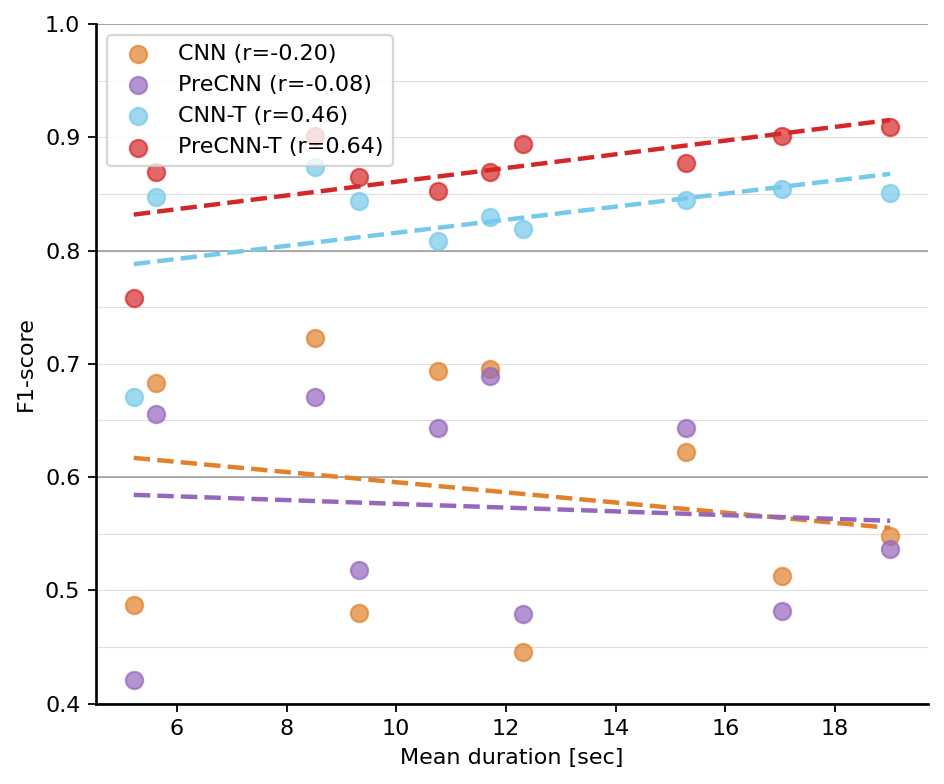

In [238]:
plt.figure(figsize=(6,5), dpi=160)
ax = plt.gca()

models = ["CNN", "PreCNN", "CNN-T", "PreCNN-T"]

colors = {
    "CNN": "#E1812C",
    "PreCNN": "#9467bd",
    "CNN-T": "#75c9eb",
    "PreCNN-T": "#d62728"
}

# ===== 背景：横線のみ =====
for y in np.arange(0, 1.01, 0.2):
    ax.axhline(y, color="gray", lw=0.9, alpha=0.6, zorder=0)
for y in np.arange(0, 1.01, 0.05):
    ax.axhline(y, color="gray", lw=0.5, alpha=0.25, zorder=0)

# ===== 枠線：左と下だけ =====
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.2)
ax.spines["bottom"].set_linewidth(1.2)

# ===== プロット =====
for model in models:
    x = df_wide["mean"]
    y = df_wide[model]

    coef = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = coef[0] * x_line + coef[1]

    corr = np.corrcoef(x, y)[0,1]

    ax.scatter(
        x, y,
        color=colors[model],
        alpha=0.7,
        s=60,
        label=f"{model} (r={corr:.2f})"
    )

    ax.plot(
        x_line, y_line,
        color=colors[model],
        linestyle="--",
        linewidth=2
    )

# ===== ラベル =====
ax.set_xlabel("Mean duration [sec]")
ax.set_ylabel("F1-score")
# ax.set_title("Relationship between activity duration and performance")
#ax.set_xlim(0, 25)
ax.set_ylim(0.4, 1.0)

# gridは使わない（axhlineで代替）
# ax.grid(False)

ax.legend()
plt.tight_layout()
plt.show()

In [239]:
df_long = df_wide.sort_values("mean", ascending=False).head(5)

display(
    df_long[[
        "label_name", "mean",
        "CNN", "PreCNN", "CNN-T", "PreCNN-T"
    ]]
)

,label_name,mean,CNN,PreCNN,CNN-T,PreCNN-T
0,Assemble Box,19.008527,0.547748,0.536903,0.850842,0.908976
8,Relocate Item Label,17.044569,0.512674,0.481689,0.854745,0.901203
9,Scan Label,15.277329,0.621717,0.643368,0.844246,0.877052
3,Close Box,12.320360,0.445138,0.479439,0.819242,0.894260
6,Picking,11.709206,0.695233,0.688828,0.829917,0.869377


In [240]:
def plot_activity_f1_and_duration(
    df_wide,
    model_names=None,
    name_dict=None,
    sort_by="mean",   # "mean" or "label"
):
    if model_names is None:
        model_names = ["CNN", "PreCNN", "CNN-T", "PreCNN-T"]

    colors = {
        "CNN": "#E1812C",
        "PreCNN": "#9467bd",
        "CNN-T": "#75c9eb",
        "PreCNN-T": "#d62728",
    }

    if sort_by == "mean":
        df_plot = df_wide.copy().sort_values("mean")
    else:
        df_plot = df_wide.copy().sort_values("label")

    x_labels = df_plot["label_name"].tolist()
    x = np.arange(len(x_labels))
    width = max(0.1, 0.75 / len(model_names))

    fig, axes = plt.subplots(
        2, 1,
        figsize=(12, 5.2),
        dpi=200,
        sharex=True,
        gridspec_kw={"height_ratios": [3, 1.2]}
    )

    ax = axes[0]

    for i, model in enumerate(model_names):
        offset = (i - (len(model_names) - 1) / 2) * width
        label_name = name_dict.get(model, model) if name_dict else model

        ax.bar(
            x + offset,
            df_plot[model].values,
            width=width,
            color=colors.get(model, None),
            edgecolor="black",
            alpha=0.9,
            label=label_name,
        )

    for y in np.arange(0, 1.01, 0.2):
        ax.axhline(y, color="gray", lw=0.9, alpha=0.6, zorder=0)
    for y in np.arange(0, 1.01, 0.05):
        ax.axhline(y, color="gray", lw=0.5, alpha=0.25, zorder=0)

    ax.set_ylim(0, 1.05)
    ax.set_ylabel("F1-score")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, 1.24),
        ncol=len(model_names),
        frameon=False,
    )

    ax2 = axes[1]

    ax2.bar(
        x,
        df_plot["mean"].values,
        width=0.55,
        color="lightgray",
        edgecolor="black",
        alpha=0.9,
        label="Mean duration",
    )

    # stdを薄いエラーバーで表示
    ax2.errorbar(
        x,
        df_plot["mean"].values,
        yerr=df_plot["std"].values,
        fmt="none",
        ecolor="gray",
        elinewidth=1.0,
        capsize=3,
        alpha=0.7,
    )

    for y in np.arange(0, max(df_plot["mean"] + df_plot["std"]) + 5, 10):
        ax2.axhline(y, color="gray", lw=0.7, alpha=0.35, zorder=0)

    ax2.set_ylabel("Duration [sec]")
    ax2.set_xlabel("Activity")
    ax2.spines["top"].set_visible(False)
    ax2.spines["right"].set_visible(False)

    ax2.set_xticks(x)
    ax2.set_xticklabels(x_labels, fontsize=9, rotation=45, ha="right")

    plt.tight_layout()
    plt.show()

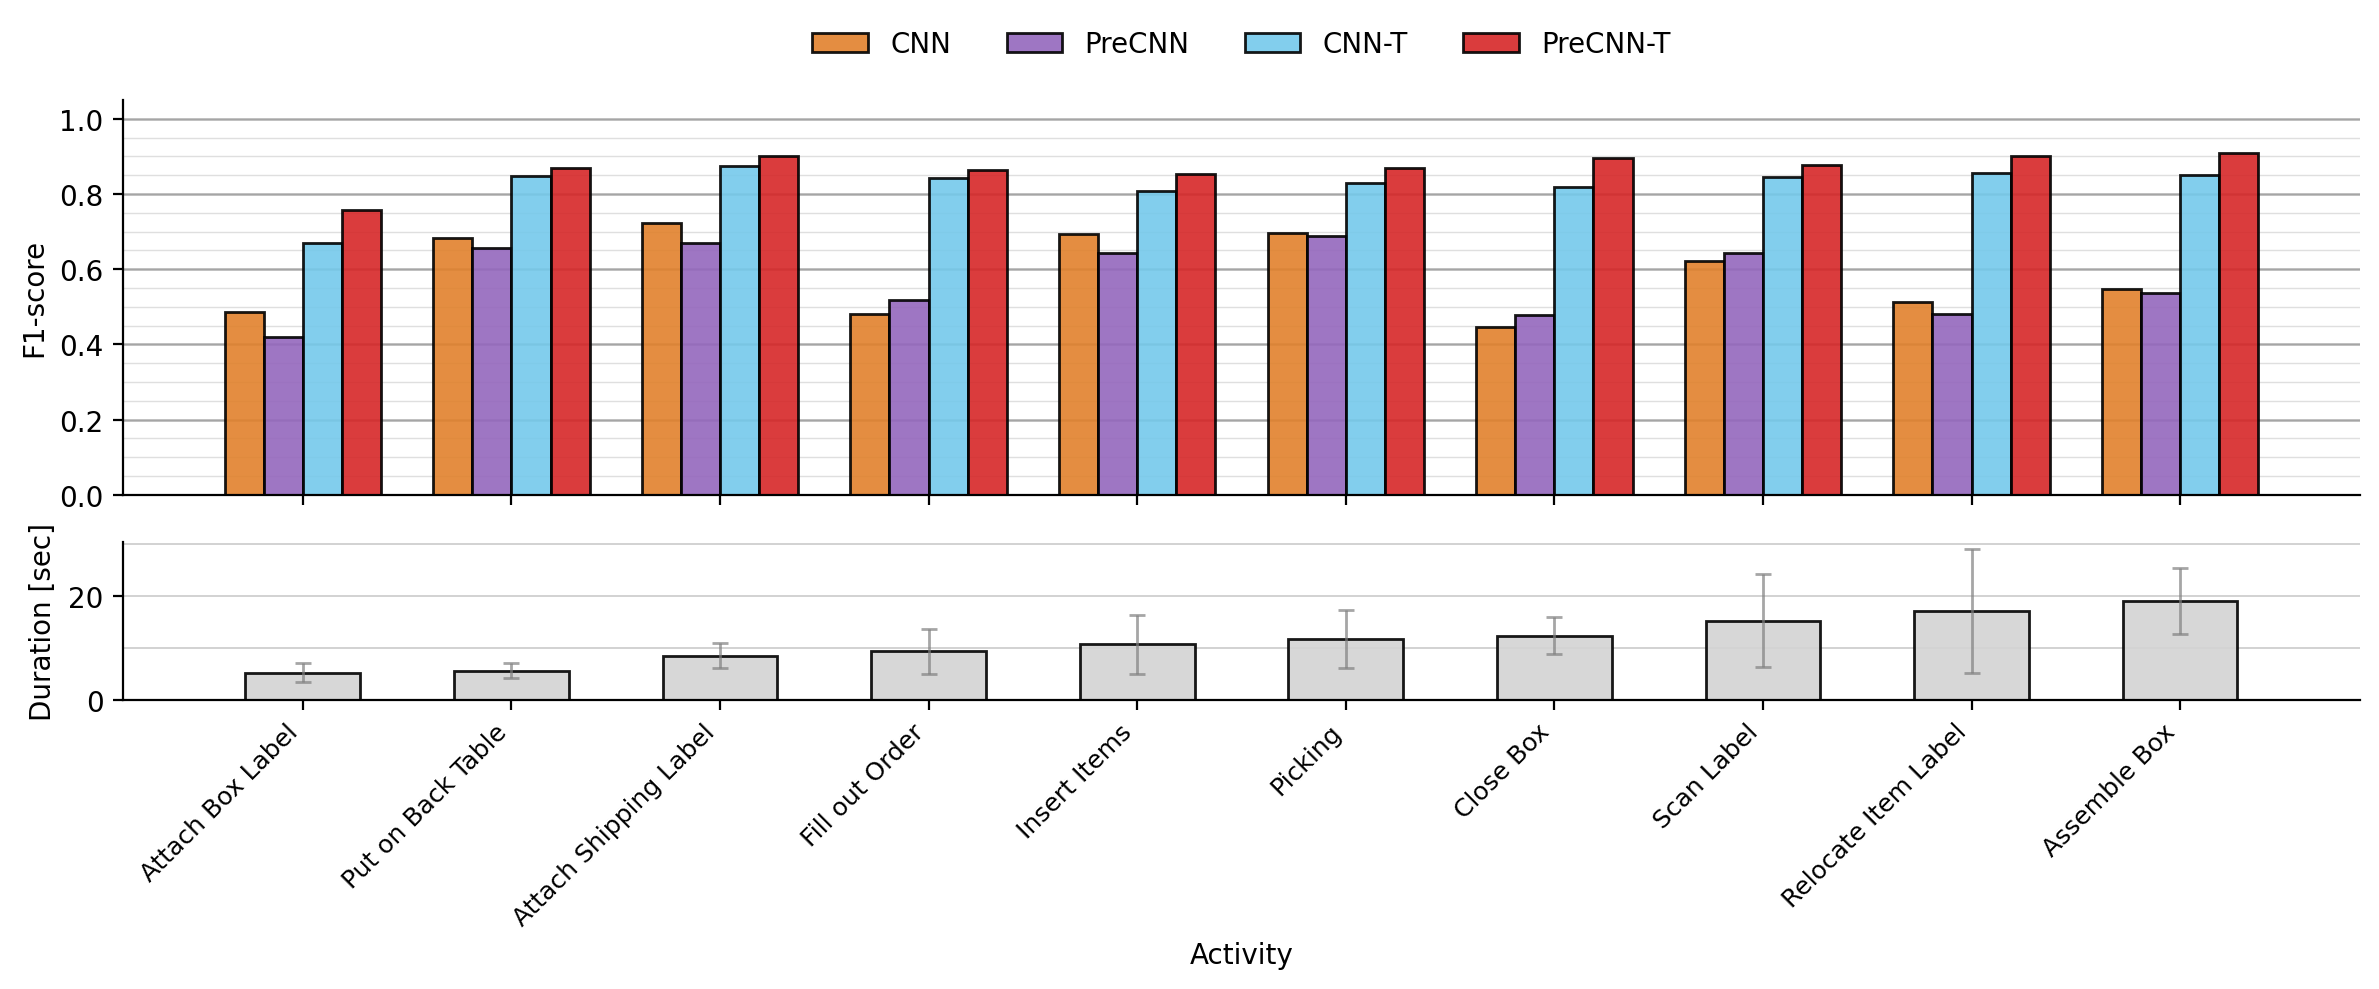

In [241]:
model_names_plot = ["CNN", "PreCNN", "CNN-T", "PreCNN-T"]

plot_activity_f1_and_duration(
    df_wide,
    model_names=["CNN", "PreCNN", "CNN-T", "PreCNN-T"],
    sort_by="mean",
)

In [242]:
def plot_activity_f1_and_duration_dist(
    df_wide,
    runs_df,
    model_names=None,
    name_dict=None,
    sort_by="mean",
):
    if model_names is None:
        model_names = ["CNN", "PreCNN", "CNN-T", "PreCNN-T"]

    colors = {
        "CNN": "#E1812C",
        "PreCNN": "#9467bd",
        "CNN-T": "#75c9eb",
        "PreCNN-T": "#d62728",
    }

    if sort_by == "mean":
        df_plot = df_wide.copy().sort_values("mean")
    else:
        df_plot = df_wide.copy().sort_values("label")

    x_labels = df_plot["label_name"].tolist()
    x = np.arange(len(x_labels))
    width = max(0.1, 0.75 / len(model_names))

    fig, axes = plt.subplots(
        2, 1,
        figsize=(12, 5.8),
        dpi=200,
        sharex=True,
        gridspec_kw={"height_ratios": [3, 1.5]}
    )

    # =====================
    # 上段: F1-score
    # =====================
    ax = axes[0]

    for i, model in enumerate(model_names):
        offset = (i - (len(model_names) - 1) / 2) * width
        label_name = name_dict.get(model, model) if name_dict else model

        ax.bar(
            x + offset,
            df_plot[model].values,
            width=width,
            color=colors.get(model, None),
            edgecolor="black",
            alpha=0.9,
            label=label_name,
            zorder=2,
        )

    for y in np.arange(0, 1.01, 0.2):
        ax.axhline(y, color="gray", lw=0.9, alpha=0.6, zorder=0)
    for y in np.arange(0, 1.01, 0.05):
        ax.axhline(y, color="gray", lw=0.5, alpha=0.25, zorder=0)

    ax.set_ylim(0, 1.05)
    ax.set_ylabel("F1-score")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, 1.24),
        ncol=len(model_names),
        frameon=False,
    )

    # =====================
    # 下段: Duration distribution
    # =====================
    ax2 = axes[1]

    duration_data = []
    for label_name in x_labels:
        vals = runs_df.loc[
            runs_df["label_name"] == label_name,
            "duration_sec"
        ].dropna().values
        duration_data.append(vals)

    ax2.boxplot(
        duration_data,
        positions=x,
        widths=0.55,
        showfliers=True,
        patch_artist=True,
        boxprops=dict(facecolor="lightgray", edgecolor="black", linewidth=1.0),
        medianprops=dict(color="black", linewidth=1.2),
        whiskerprops=dict(color="gray", linewidth=1.0),
        capprops=dict(color="gray", linewidth=1.0),
        flierprops=dict(
            marker="o",
            markersize=2.5,
            markerfacecolor="gray",
            markeredgecolor="gray",
            alpha=0.35,
        ),
    )

    ax2.set_ylabel("Duration [sec]")
    ax2.set_xlabel("Activity")
    ax2.set_ylim(0, max(df_plot["mean"] + df_plot["std"]) + 5)
    ax2.spines["top"].set_visible(False)
    ax2.spines["right"].set_visible(False)

    ax2.set_xticks(x)
    ax2.set_xticklabels(x_labels, fontsize=9, rotation=45, ha="right")

    ax2.grid(axis="y", color="gray", alpha=0.25, linewidth=0.7)

    plt.tight_layout()
    
    plt.show()


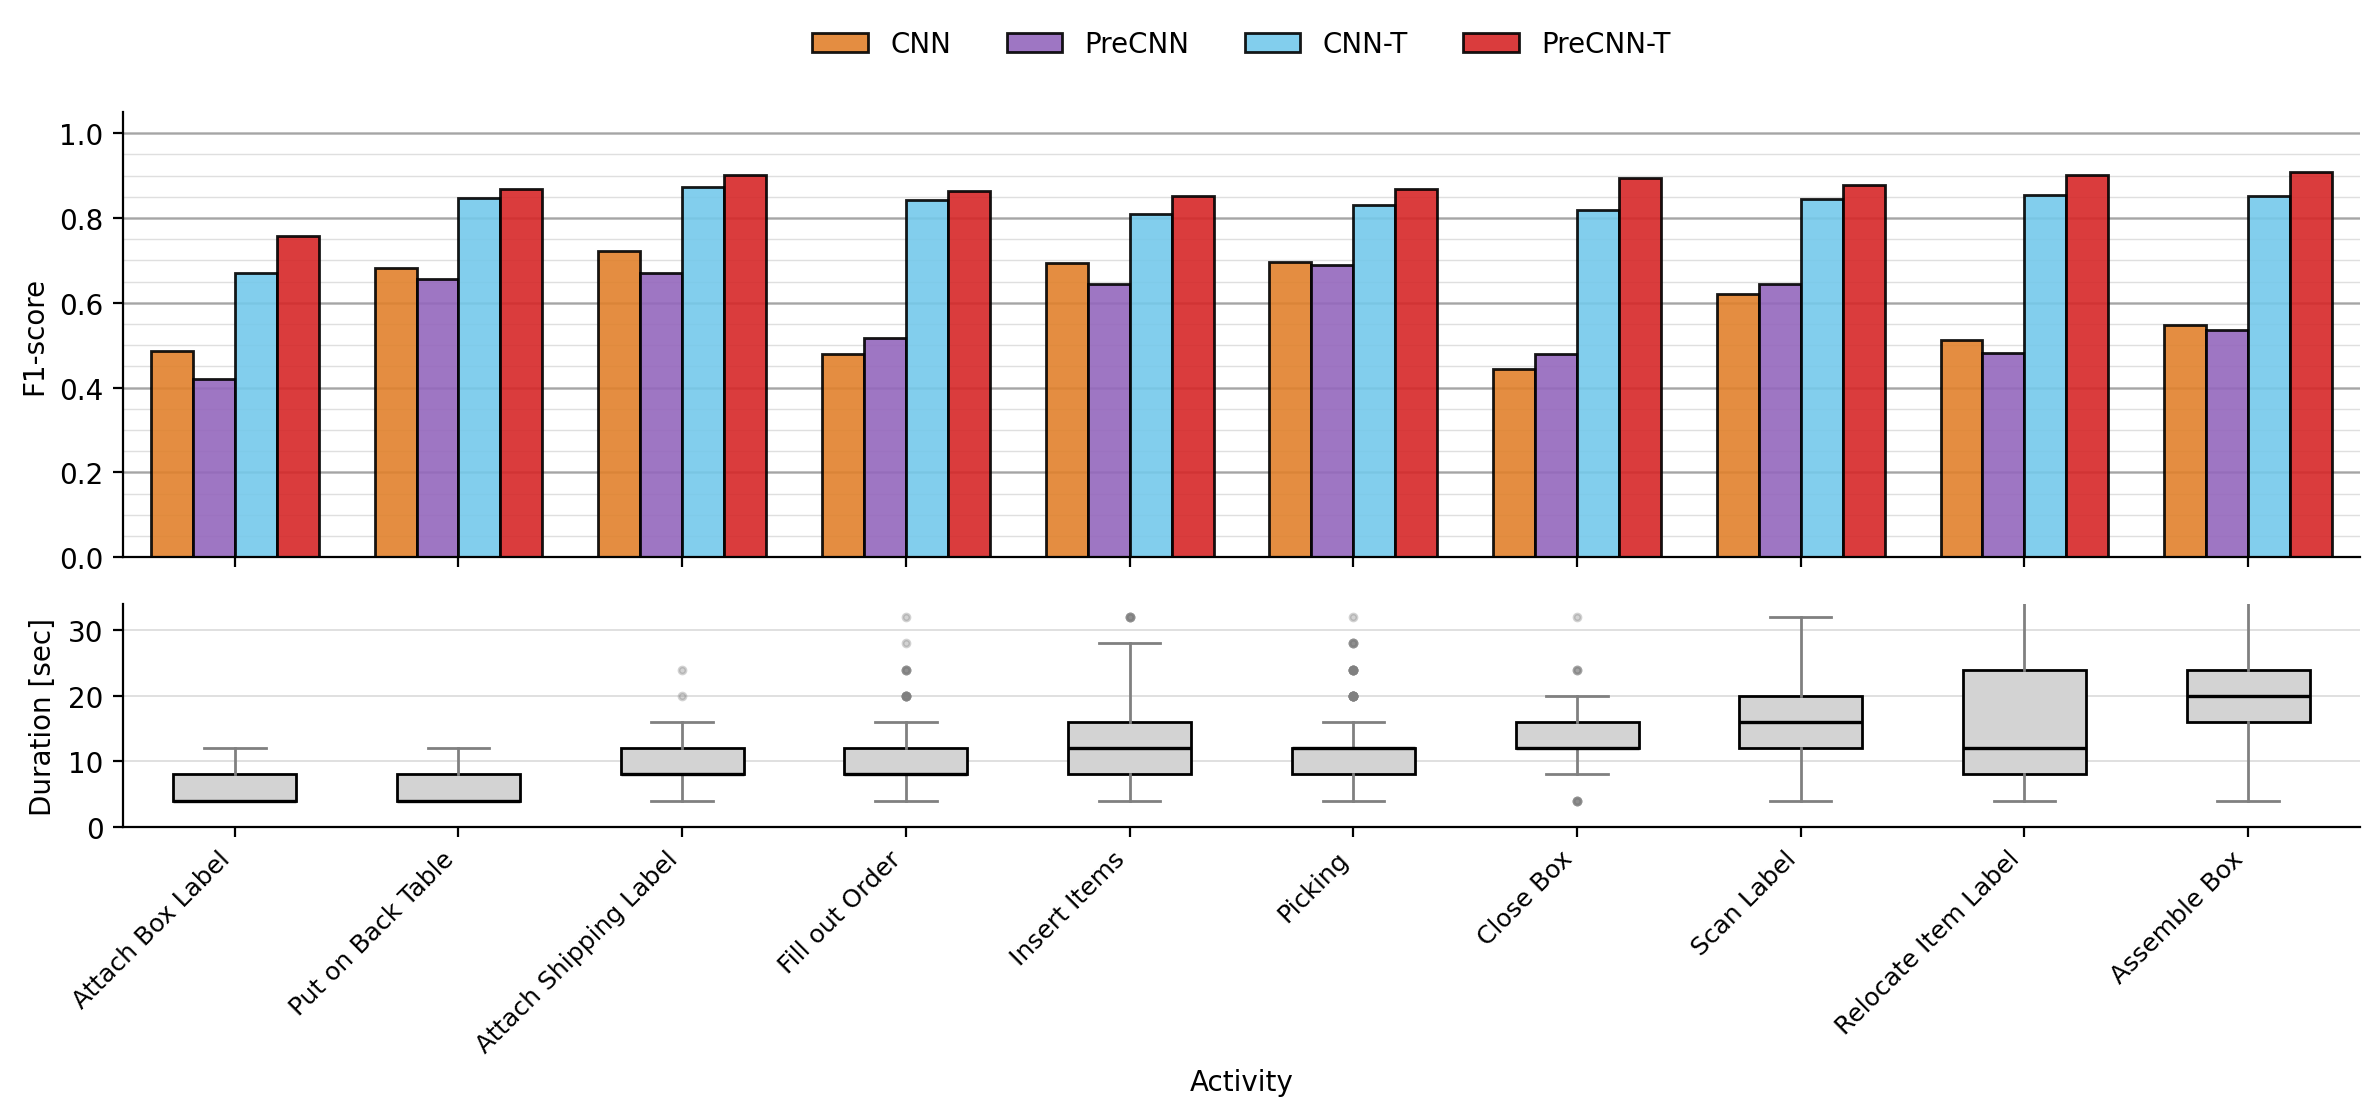

In [243]:
runs_df = collect_runs_for_model(
    outputs["PreCNN-T"],
    stride_sec=4
)

runs_df["label_name"] = runs_df["label"].map(
    {i: name for i, name in enumerate(label_names)}
)

plot_activity_f1_and_duration_dist(
    df_wide,
    runs_df,
    model_names=["CNN", "PreCNN", "CNN-T", "PreCNN-T"],
    sort_by="mean",
)

In [266]:
import numpy as np
import matplotlib.pyplot as plt

def plot_duration_boxplot(df_wide, runs_df, sort_by="mean", ylim=(0, 120)):
    if sort_by == "mean":
        df_plot = df_wide.copy().sort_values("mean")
    else:
        df_plot = df_wide.copy().sort_values("label")

    x_labels = df_plot["label_name"].tolist()
    x = np.arange(len(x_labels))

    duration_data = []
    for label_name in x_labels:
        vals = runs_df.loc[
            runs_df["label_name"] == label_name,
            "duration_sec"
        ].dropna().values
        duration_data.append(vals)

    fig, ax = plt.subplots(figsize=(10, 4), dpi=200)

    ax.boxplot(
        duration_data,
        positions=x,
        widths=0.6,
        showfliers=True,
        patch_artist=True,
        boxprops=dict(facecolor="lightgray", edgecolor="black", linewidth=1.0),
        medianprops=dict(color="black", linewidth=1.2),
        whiskerprops=dict(color="gray", linewidth=1.0),
        capprops=dict(color="gray", linewidth=1.0),
        flierprops=dict(
            marker="o",
            markersize=2.5,
            markerfacecolor="gray",
            markeredgecolor="gray",
            alpha=0.4,
        ),
    )

    ax.set_ylim(*ylim)   # ← boxplotの後、showの前

    ax.set_ylabel("Duration [sec]")
    ax.set_xlabel("Activity")
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=9)

    ax.grid(axis="y", color="gray", alpha=0.25, linewidth=0.7)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.show()

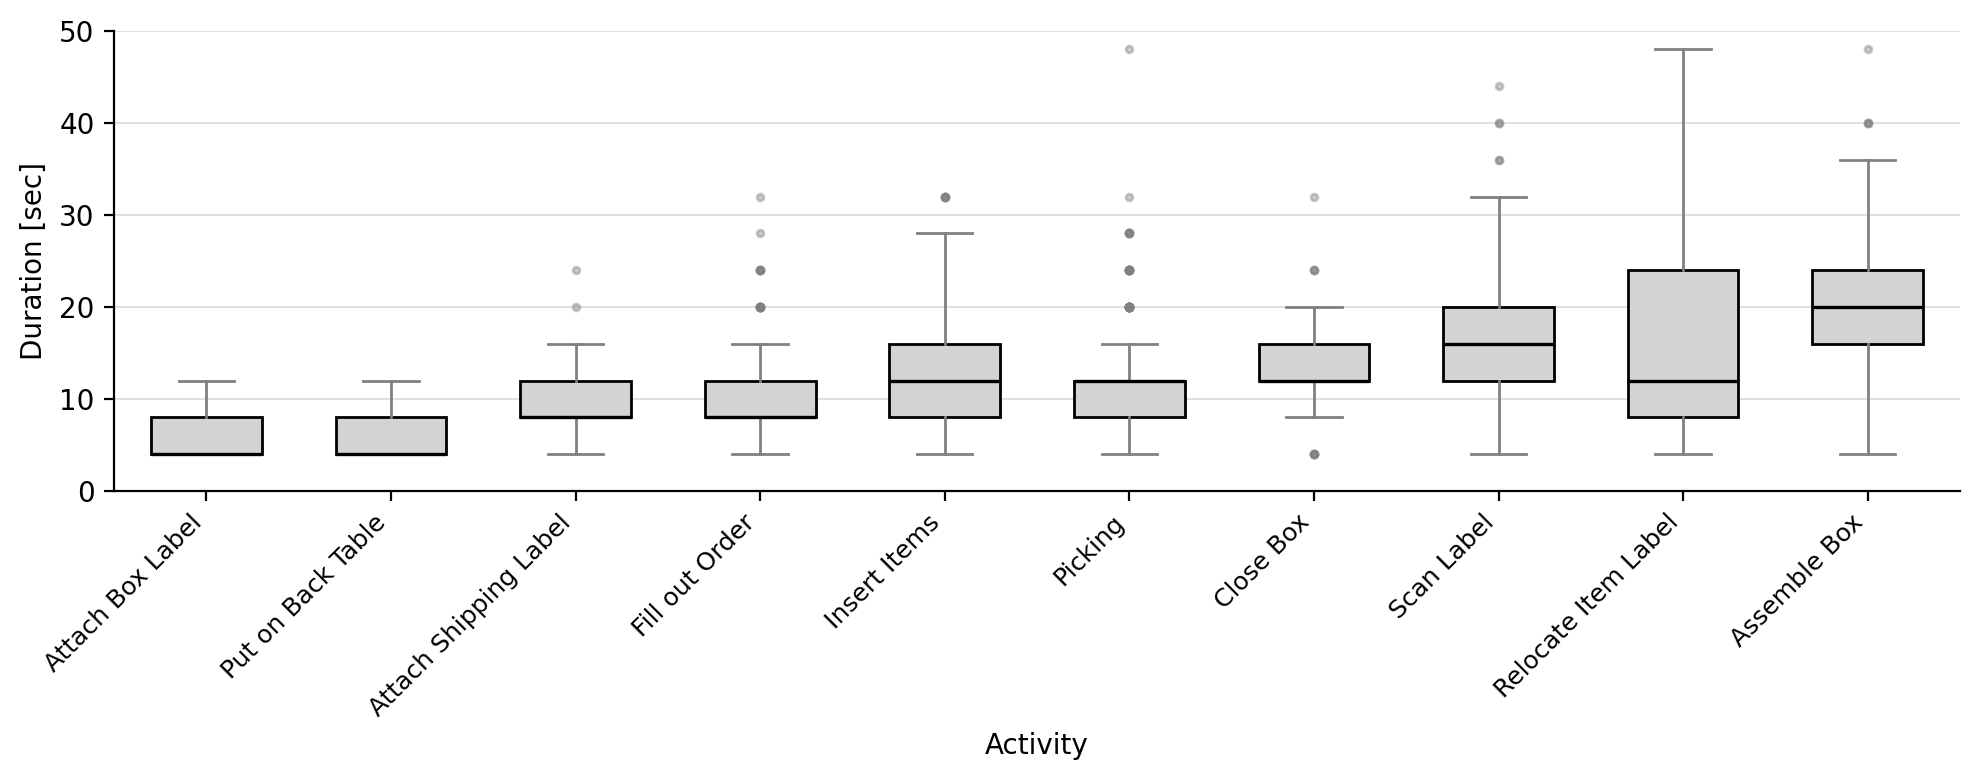

In [269]:
plot_duration_boxplot(df_wide, runs_df, sort_by="mean",ylim=(0, 50))

In [244]:
print(df_wide[["label_name", "mean"]])

print(
    runs_df.groupby("label_name")["duration_sec"]
    .mean()
    .reset_index()
)

              label_name       mean
0           Assemble Box  19.008527
1       Attach Box Label   5.212703
2  Attach Shipping Label   8.524605
3              Close Box  12.320360
4         Fill out Order   9.319916
5           Insert Items  10.753138
6                Picking  11.709206
7      Put on Back Table   5.615598
8    Relocate Item Label  17.044569
9             Scan Label  15.277329
              label_name  duration_sec
0           Assemble Box     20.305732
1       Attach Box Label      5.777778
2  Attach Shipping Label      9.106667
3              Close Box     13.163399
4         Fill out Order     10.128814
5           Insert Items     11.690323
6                Picking     12.338983
7      Put on Back Table      5.953125
8    Relocate Item Label     18.246753
9             Scan Label     17.012987


In [245]:
# ===== 表用データ作成 =====

df_table = df_wide.copy()

df_table = df_table[[
    "label_name",
    "mean",     # 平均持続時間
    "CNN",
    "PreCNN",
    "CNN-T",
    "PreCNN-T",
    #"support_mean"
]]

# 見やすく丸める
df_table = df_table.rename(columns={
    "label_name": "Activity",
    "mean": "Mean duration [sec]",
    #"support_mean": "Support"
})

# df_table[["Mean duration [sec]", "CNN", "PreCNN", "CNN-T", "PreCNN-T"]] = \
#     df_table[["Mean duration [sec]", "CNN", "PreCNN", "CNN-T", "PreCNN-T"]].round(2)
# df_table[["Mean duration [sec]", "CNN", "PreCNN", "CNN-T", "PreCNN-T"]] = \
#     df_table[["Mean duration [sec]", "CNN", "PreCNN", "CNN-T", "PreCNN-T"]].round(2)


# duration順でソート
df_table = df_table.sort_values("Mean duration [sec]")

df_table

,Activity,Mean duration [sec],CNN,PreCNN,CNN-T,PreCNN-T
1,Attach Box Label,5.212703,0.486716,0.420863,0.670236,0.758130
7,Put on Back Table,5.615598,0.683157,0.655702,0.847059,0.869136
2,Attach Shipping Label,8.524605,0.722653,0.670300,0.873343,0.901019
4,Fill out Order,9.319916,0.479769,0.517906,0.843407,0.864569
5,Insert Items,10.753138,0.693333,0.643700,0.808824,0.852910
6,Picking,11.709206,0.695233,0.688828,0.829917,0.869377
3,Close Box,12.320360,0.445138,0.479439,0.819242,0.894260
9,Scan Label,15.277329,0.621717,0.643368,0.844246,0.877052
8,Relocate Item Label,17.044569,0.512674,0.481689,0.854745,0.901203
0,Assemble Box,19.008527,0.547748,0.536903,0.850842,0.908976


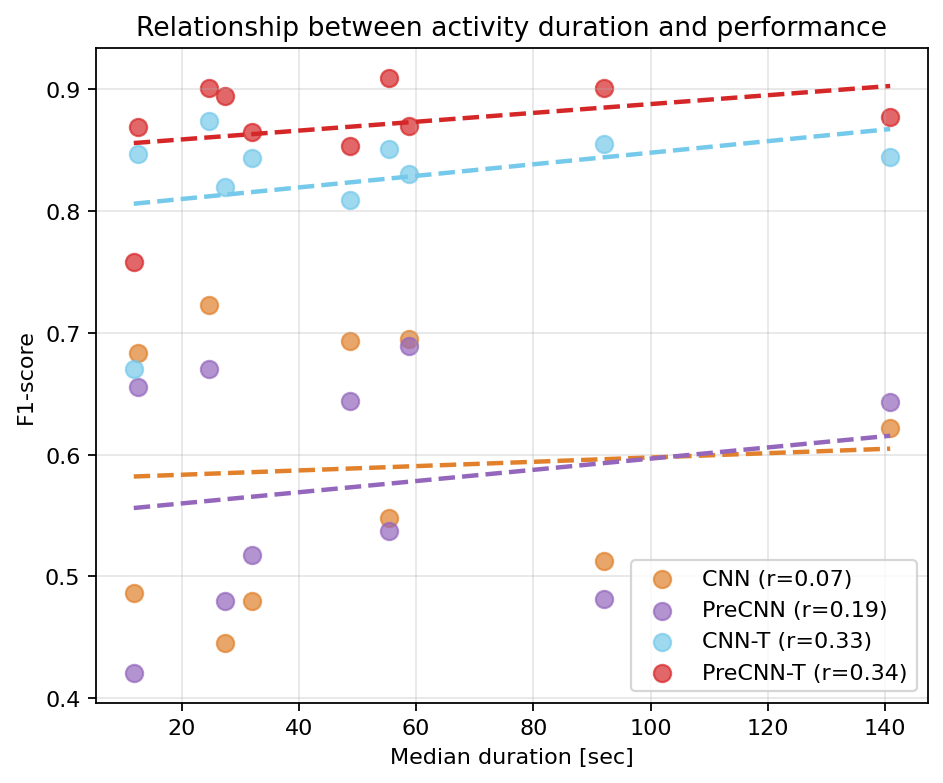

In [292]:
plt.figure(figsize=(6,5), dpi=160)

models = ["CNN", "PreCNN", "CNN-T", "PreCNN-T"]

colors = {
    "CNN": "#E1812C", #"black",
    "PreCNN": "#9467bd", #"red",
    "CNN-T": "#75c9eb", #"orange",
    "PreCNN-T": "#d62728" #"blue"
}

for model in models:
    x = df_wide["max"]
    y = df_wide[model]

    # 回帰直線
    coef = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = coef[0] * x_line + coef[1]

    # 相関
    corr = np.corrcoef(x, y)[0,1]

    plt.scatter(
        x, y,
        color=colors[model],
        alpha=0.7,
        s=60,
        label=f"{model} (r={corr:.2f})"
    )

    plt.plot(
        x_line, y_line,
        color=colors[model],
        linestyle="--",
        linewidth=2
    )

# ラベル（重なり防止で少し右に）
for _, r in df_wide.iterrows():
    #plt.text(r["median"] + 0.3, r["PreCNN-T"], r["label_name"], fontsize=9)
    pass

plt.xlabel("Median duration [sec]")
plt.ylabel("F1-score")
plt.title("Relationship between activity duration and performance")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [283]:
import numpy as np
import matplotlib.pyplot as plt

def extract_true_runs_with_pred(y_true, y_pred, stride_sec=4):
    runs = []
    start = 0
    cur = y_true[0]

    for i in range(1, len(y_true)):
        if y_true[i] != cur:
            yt = y_true[start:i]
            yp = y_pred[start:i]
            acc = np.mean(yp == cur)

            runs.append({
                "label": int(cur),
                "start": start,
                "end": i,
                "duration_sec": (i - start) * stride_sec,
                "acc": acc,
                "majority_correct": acc > 0.5,
                "all_correct": acc == 1.0,
            })

            start = i
            cur = y_true[i]

    yt = y_true[start:]
    yp = y_pred[start:]
    acc = np.mean(yp == cur)

    runs.append({
        "label": int(cur),
        "start": start,
        "end": len(y_true),
        "duration_sec": (len(y_true) - start) * stride_sec,
        "acc": acc,
        "majority_correct": acc > 0.5,
        "all_correct": acc == 1.0,
    })

    return runs
plt.show()

def collect_runs_for_model(outputs_one_model, stride_sec=4):
    rows = []

    for rec in outputs_one_model["records"]:
        user = rec["user"]
        y_true = rec["y_true"]
        y_pred = rec["y_pred"]

        for r in extract_true_runs_with_pred(y_true, y_pred, stride_sec):
            r["user"] = user
            rows.append(r)

    return pd.DataFrame(rows)

def collect_runs_for_model(outputs_one_model, stride_sec=4):
    rows = []

    for rec in outputs_one_model["records"]:
        user = rec["user"]
        y_true = rec["y_true"]
        y_pred = rec["y_pred"]

        for r in extract_true_runs_with_pred(y_true, y_pred, stride_sec):
            r["user"] = user
            rows.append(r)

    return pd.DataFrame(rows)

def collect_runs_for_model(outputs_one_model, stride_sec=4):
    rows = []

    for rec in outputs_one_model["records"]:
        user = rec["user"]
        y_true = rec["y_true"]
        y_pred = rec["y_pred"]

        for r in extract_true_runs_with_pred(y_true, y_pred, stride_sec):
            r["user"] = user
            rows.append(r)

    return pd.DataFrame(rows)

def plot_duration_distribution_by_model(
    outputs,
    target_label,
    label_names,
    models=("CNN", "PreCNN", "CNN-T", "PreCNN-T"),
    stride_sec=4,
    bins=np.arange(0, 65, 4),
    correct_key="majority_correct",
):
    fig, axes = plt.subplots(
        1, len(models),
        figsize=(15, 3),
        dpi=200,
        sharex=True,
        sharey=True
    )

    color_map = {
        "CNN": "#E1812C",
        "PreCNN": "#9467bd",
        "CNN-T": "#75c9eb",
        "PreCNN-T": "#d62728",
    }

    for ax, model in zip(axes, models):
        df_runs = collect_runs_for_model(outputs[model], stride_sec=stride_sec)
        df_target = df_runs[df_runs["label"] == target_label]

        all_dur = df_target["duration_sec"].values
        correct_dur = df_target[df_target[correct_key]]["duration_sec"].values

        ax.set_ylim([0,200])

        ax.hist(
            all_dur,
            bins=bins,
            color="lightgray",
            edgecolor="gray",
            alpha=0.8,
            label="All"
        )

        ax.hist(
            correct_dur,
            bins=bins,
            color=color_map.get(model, "tab:blue"),
            edgecolor="black",
            alpha=0.75,
            label="Correct"
        )

        run_acc = len(correct_dur) / len(all_dur) if len(all_dur) > 0 else np.nan

        ax.set_title(f"{model} run_acc: {run_acc:.2f}", fontsize=10)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        for y in ax.get_yticks():
            ax.axhline(y, color="gray", lw=0.4, alpha=0.25, zorder=0)

    axes[0].set_ylabel("Frequency")
    for ax in axes:
        ax.set_xlabel("Duration [sec]")
        #ax.set_ylim([0,200])

    fig.suptitle(
        f"Duration distribution and correctly recognized runs: {label_names[target_label]}",
        y=1.05,
        fontsize=12
    )

    axes[-1].legend(frameon=False, fontsize=9)
    plt.tight_layout()
    plt.show()

    

In [248]:

display(df_plot.sort_values("f1"))

,label,label_name,count,mean,median,std,min,max,CNN,PreCNN,CNN-T,f1
1,1,Attach Box Label,310,5.212703,4.863,1.802962,1.425,11.836,0.486716,0.420863,0.670236,0.758130
5,5,Insert Items,319,10.753138,9.583,5.672381,1.871,48.753,0.693333,0.643700,0.808824,0.852910
4,4,Fill out Order,321,9.319916,8.301,4.280312,0.927,32.074,0.479769,0.517906,0.843407,0.864569
7,7,Put on Back Table,276,5.615598,5.707,1.490385,0.488,12.589,0.683157,0.655702,0.847059,0.869136
6,6,Picking,310,11.709206,10.476,5.644220,1.648,58.794,0.695233,0.688828,0.829917,0.869377
9,9,Scan Label,325,15.277329,14.068,8.993910,0.875,140.857,0.621717,0.643368,0.844246,0.877052
3,3,Close Box,314,12.320360,12.085,3.551590,1.893,27.408,0.445138,0.479439,0.819242,0.894260
2,2,Attach Shipping Label,311,8.524605,8.337,2.406390,0.255,24.732,0.722653,0.670300,0.873343,0.901019
8,8,Relocate Item Label,313,17.044569,12.599,11.918053,2.851,92.019,0.512674,0.481689,0.854745,0.901203
0,0,Assemble Box,319,19.008527,18.411,6.396827,2.764,55.386,0.547748,0.536903,0.850842,0.908976


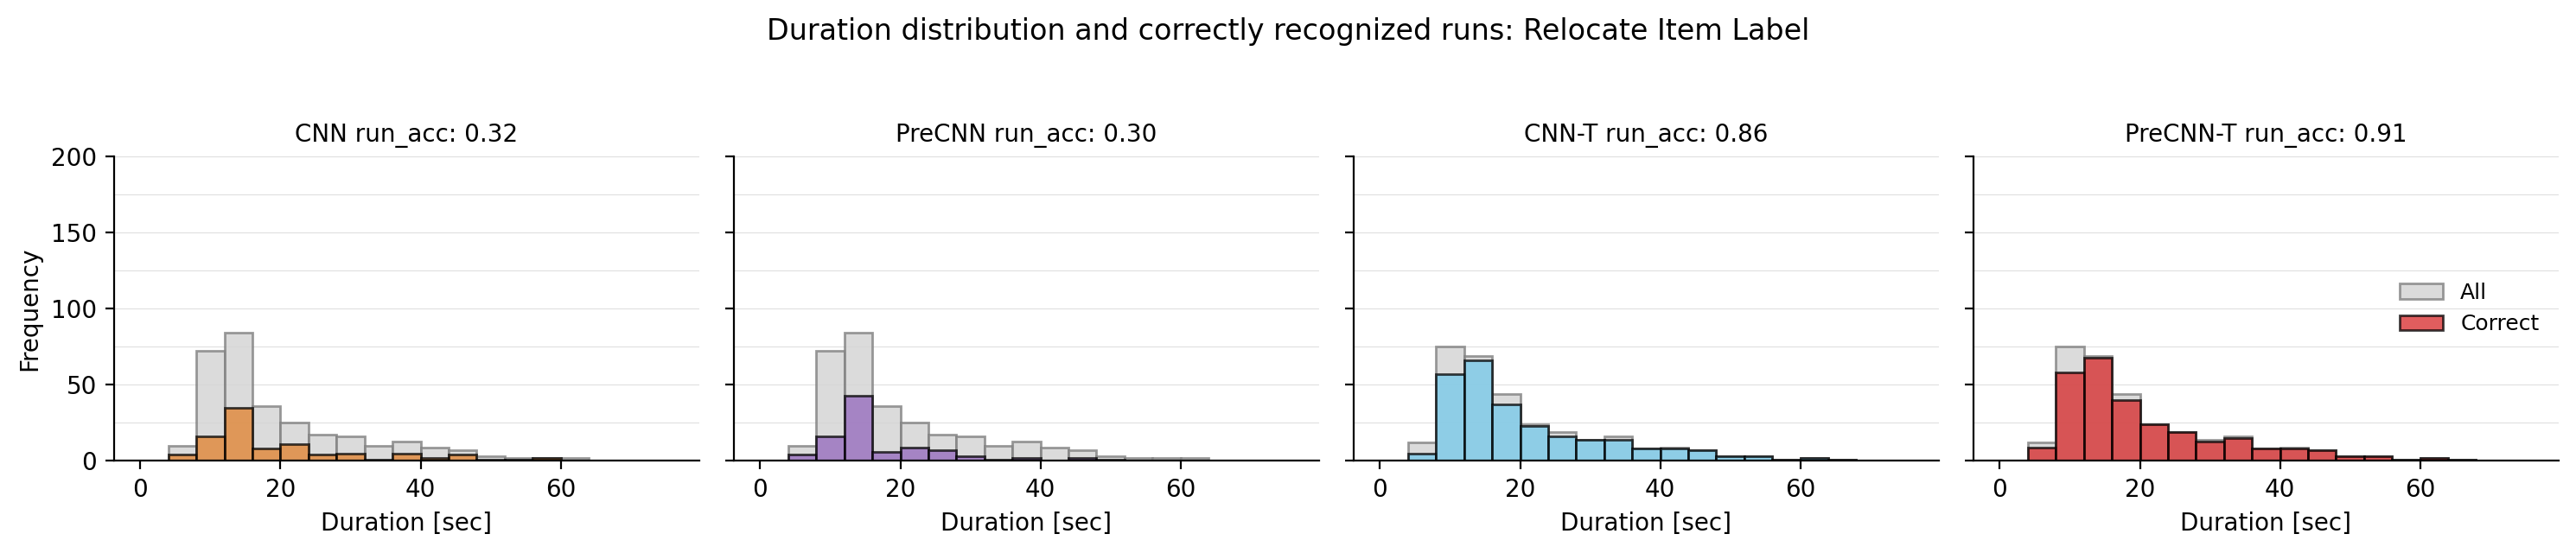

In [284]:
target_label = label_names.index("Relocate Item Label")

plot_duration_distribution_by_model(
    outputs,
    target_label=target_label,
    label_names=label_names,
    stride_sec=4,
    bins=np.arange(0, 80, 4),
    correct_key="majority_correct",  # run内の過半数が正解ならCorrect
)

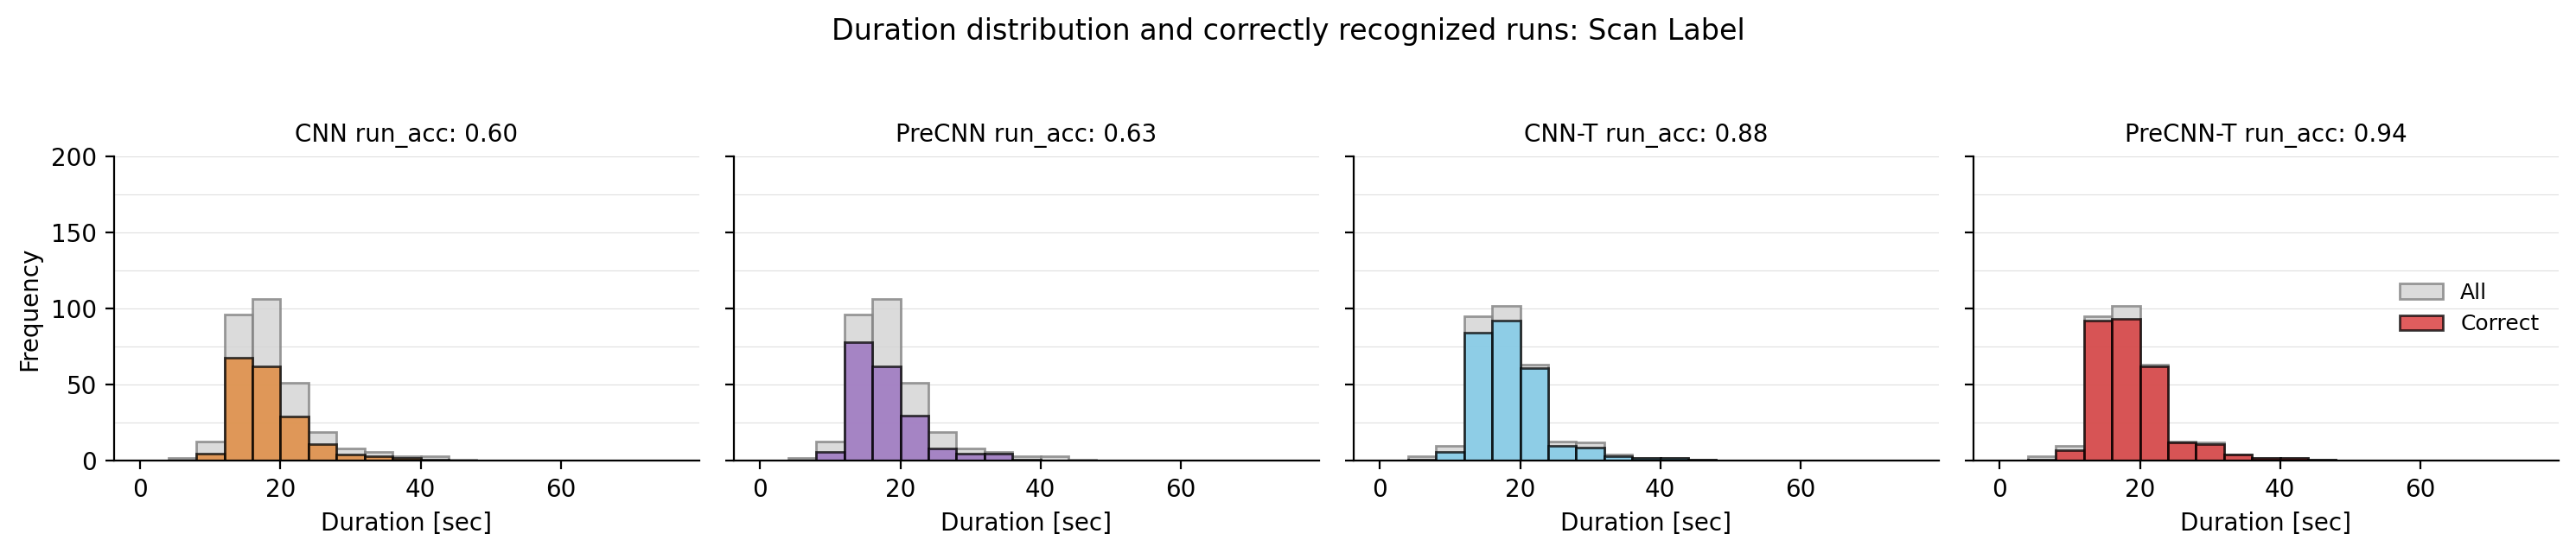

In [294]:
target_label = label_names.index("Scan Label")

plot_duration_distribution_by_model(
    outputs,
    target_label=target_label,
    label_names=label_names,
    stride_sec=4,
    bins=np.arange(0, 80, 4),
    correct_key="majority_correct",  # run内の過半数が正解ならCorrect
)

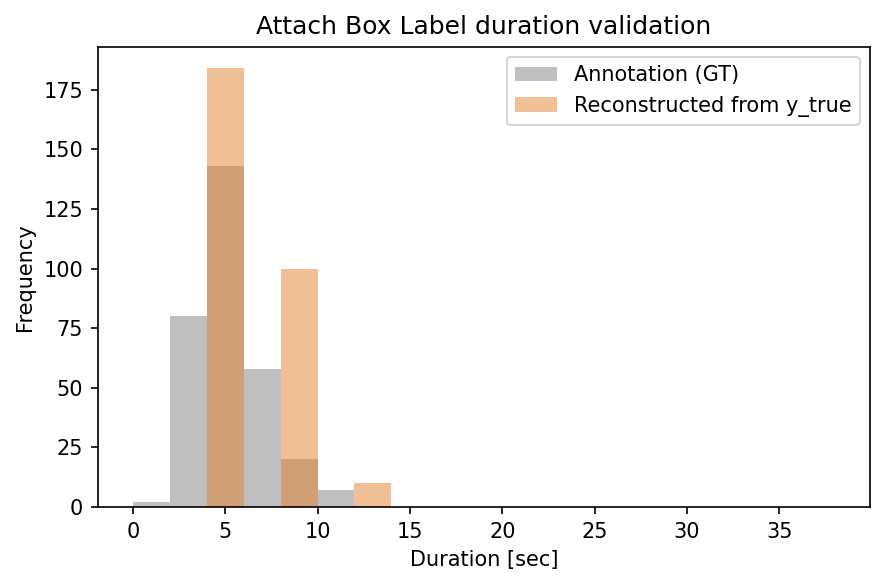

In [251]:
target_label = label_names.index("Attach Box Label")

# --- GT annotation ---
df_gt_attach = df_true[df_true["label_name"] == "Attach Box Label"]

# --- y_trueから復元 ---
df_runs_cnn = collect_runs_for_model(outputs["CNN"], stride_sec=4)
df_runs_attach = df_runs_cnn[df_runs_cnn["label"] == target_label]

# --- plot ---
plt.figure(figsize=(6,4), dpi=150)

bins = np.arange(0, 40, 2)

plt.hist(
    df_gt_attach["duration_sec"],
    bins=bins,
    alpha=0.5,
    label="Annotation (GT)",
    color="gray"
)

plt.hist(
    df_runs_attach["duration_sec"],
    bins=bins,
    alpha=0.5,
    label="Reconstructed from y_true",
    color="#E1812C"
)

plt.xlabel("Duration [sec]")
plt.ylabel("Frequency")
plt.legend()
plt.title("Attach Box Label duration validation")

plt.tight_layout()
plt.show()

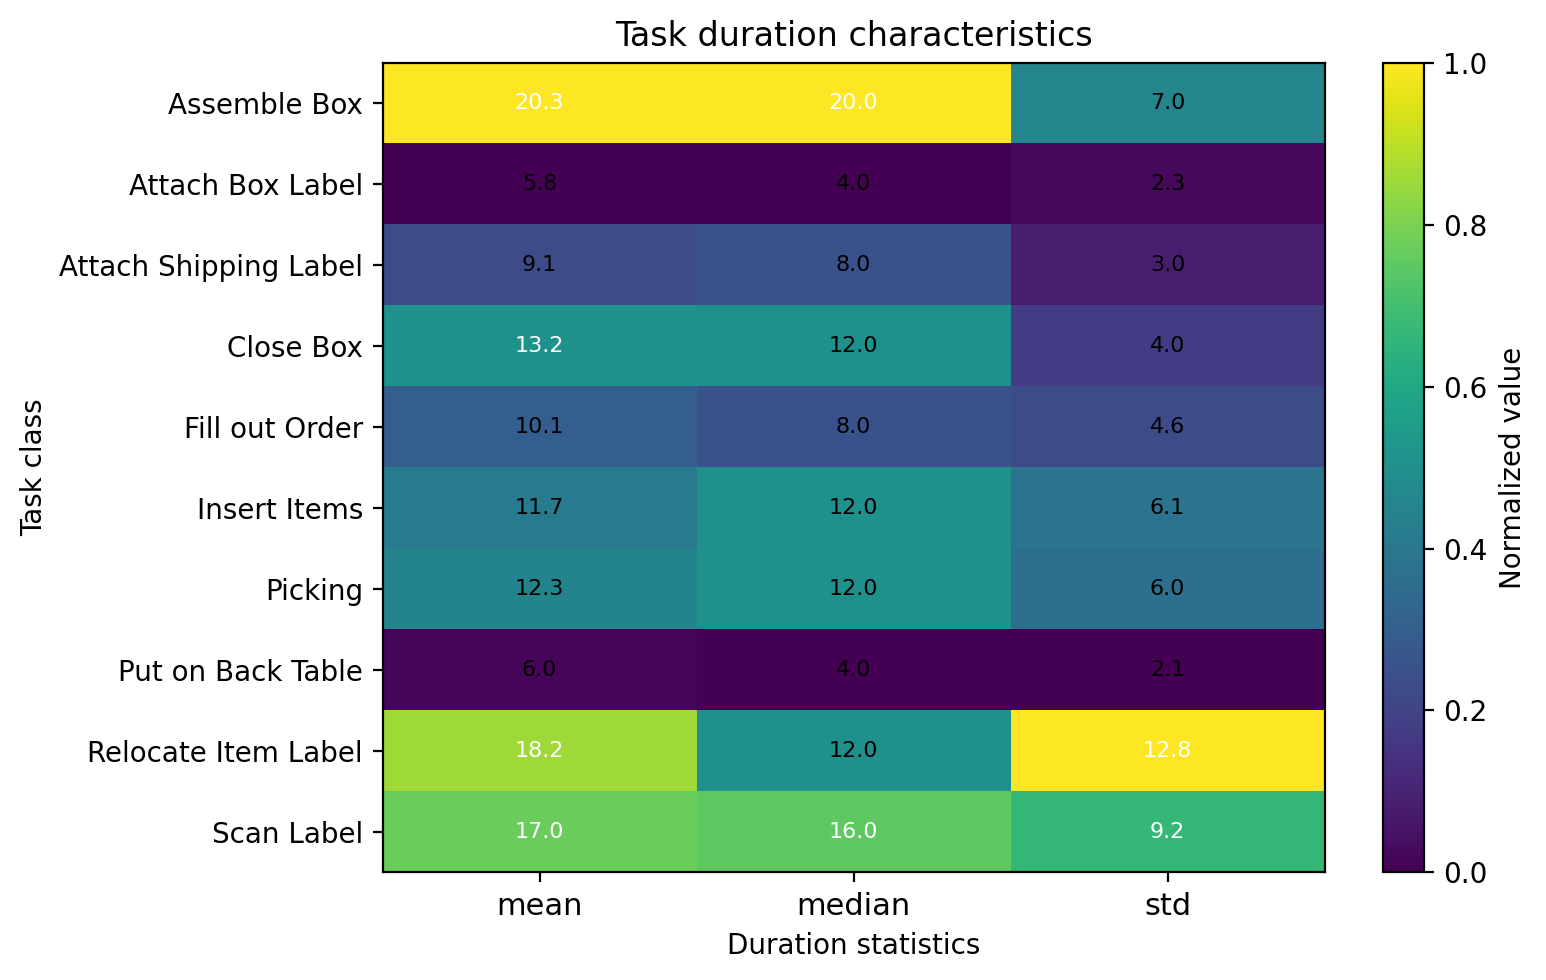

,Task,mean,median,std,min,max,num_runs
0,Assemble Box,20.31,20.0,6.96,4,60,314
1,Attach Box Label,5.78,4.0,2.31,4,12,297
2,Attach Shipping Label,9.11,8.0,2.96,4,24,300
3,Close Box,13.16,12.0,3.95,4,32,306
4,Fill out Order,10.13,8.0,4.58,4,32,295
5,Insert Items,11.69,12.0,6.14,4,52,310
6,Picking,12.34,12.0,6.00,4,60,295
7,Put on Back Table,5.95,4.0,2.09,4,12,256
8,Relocate Item Label,18.25,12.0,12.76,4,104,308
9,Scan Label,17.01,16.0,9.19,4,144,308


In [252]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 正解ラベルから作業区間を抽出
# =========================

def extract_true_runs(y_true, stride_sec=4):
    y_true = np.asarray(y_true)
    runs = []

    if len(y_true) == 0:
        return runs

    start = 0
    cur = y_true[0]

    for i in range(1, len(y_true)):
        if y_true[i] != cur:
            runs.append({
                "label": int(cur),
                "duration_sec": (i - start) * stride_sec,
            })
            start = i
            cur = y_true[i]

    runs.append({
        "label": int(cur),
        "duration_sec": (len(y_true) - start) * stride_sec,
    })

    return runs


def collect_true_runs(outputs_one_model, stride_sec=4):
    rows = []

    for rec in outputs_one_model["records"]:
        user = rec["user"]
        y_true = np.asarray(rec["y_true"])

        for r in extract_true_runs(y_true, stride_sec=stride_sec):
            r["user"] = user
            rows.append(r)

    return pd.DataFrame(rows)


# =========================
# 統計量ヒートマップ
# =========================

def plot_duration_stat_heatmap(
    outputs,
    model_name,
    label_names,
    stride_sec=4,
    stats=("mean", "median", "std", "min", "max", "num_runs"),
    normalize=True,
    annotate=True,
):
    df_runs = collect_true_runs(
        outputs[model_name],
        stride_sec=stride_sec
    )

    rows = []

    for c, name in enumerate(label_names):
        durations = df_runs[df_runs["label"] == c]["duration_sec"].values

        row = {"Task": name}

        if len(durations) == 0:
            row.update({
                "mean": np.nan,
                "median": np.nan,
                "std": np.nan,
                "min": np.nan,
                "max": np.nan,
                "num_runs": 0,
            })
        else:
            row.update({
                "mean": np.mean(durations),
                "median": np.median(durations),
                "std": np.std(durations),
                "min": np.min(durations),
                "max": np.max(durations),
                "num_runs": len(durations),
            })

        rows.append(row)

    df_stat = pd.DataFrame(rows)
    mat_raw = df_stat[list(stats)].values.astype(float)

    if normalize:
        # 各統計量ごとに0〜1正規化
        col_min = np.nanmin(mat_raw, axis=0, keepdims=True)
        col_max = np.nanmax(mat_raw, axis=0, keepdims=True)
        mat_plot = (mat_raw - col_min) / np.maximum(col_max - col_min, 1e-8)
        cbar_label = "Normalized value"
    else:
        mat_plot = mat_raw
        cbar_label = "Value"

    fig, ax = plt.subplots(figsize=(8, 5), dpi=200)

    im = ax.imshow(
        mat_plot,
        aspect="auto",
        interpolation="nearest",
        vmin=0 if normalize else None,
        vmax=1 if normalize else None,
    )

    ax.set_xticks(np.arange(len(stats)))
    ax.set_xticklabels(stats, fontsize=11)

    ax.set_yticks(np.arange(len(label_names)))
    ax.set_yticklabels(label_names, fontsize=10)

    ax.set_xlabel("Duration statistics")
    ax.set_ylabel("Task class")
    ax.set_title("Task duration characteristics")

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(cbar_label)

    if annotate:
        for i in range(len(label_names)):
            for j, stat in enumerate(stats):
                value = mat_raw[i, j]

                if np.isnan(value):
                    text = "-"
                elif stat == "num_runs":
                    text = f"{int(value)}"
                else:
                    text = f"{value:.1f}"

                ax.text(
                    j,
                    i,
                    text,
                    ha="center",
                    va="center",
                    fontsize=8,
                    color="white" if mat_plot[i, j] > 0.5 else "black",
                )

    plt.tight_layout()
    plt.show()

    return df_stat


df_duration_stat = plot_duration_stat_heatmap(
    outputs=outputs,
    model_name="PreCNN-T",  # durationはy_true由来なので，基本どのモデルでもOK
    label_names=label_names,
    stride_sec=4,
    stats=("mean", "median", "std"),
    normalize=True,
    annotate=True,
)

display(df_duration_stat.round(2))

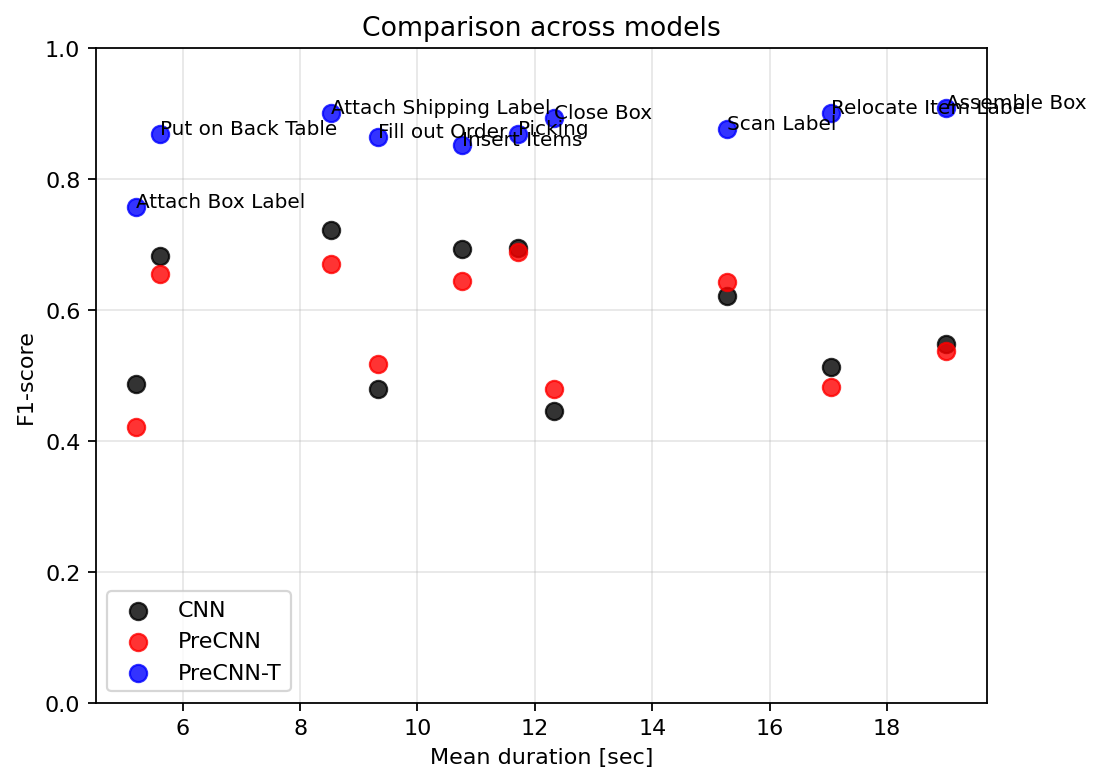

In [253]:
plt.figure(figsize=(7,5), dpi=160)

colors = {
    "CNN": "black",
    "PreCNN": "red",
    "PreCNN-T": "blue"
}

for model in ["CNN", "PreCNN", "PreCNN-T"]:
    plt.scatter(
        df_wide["mean"],   # ← mean推奨
        df_wide[model],
        color=colors[model],
        label=model,
        s=60,
        alpha=0.8
    )

# ラベル（PreCNN-Tの位置に付けると見やすい）
for _, row in df_wide.iterrows():
    plt.text(row["mean"], row["PreCNN-T"], row["label_name"], fontsize=9)

plt.xlabel("Mean duration [sec]")
plt.ylabel("F1-score")
plt.ylim(0, 1)
plt.title("Comparison across models")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [254]:
df_wide["boost"] = (
    (df_wide["PreCNN-T"] - df_wide["CNN-T"])
    - (df_wide["PreCNN"] - df_wide["CNN"])
)

In [255]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

def plot_pretrain_arrow_effect(
    df,
    base_col,
    target_col,
    title,
    ylabel="F1-score",
    x_col="mean",
):
    fig, ax = plt.subplots(figsize=(7, 5), dpi=160)

    cmap = LinearSegmentedColormap.from_list("blue_to_red", ["#377eb8", "#e41a1c"])

    for _, row in df.iterrows():
        x = row[x_col]
        y0 = row[base_col]
        y1 = row[target_col]

        # before point
        ax.scatter(x, y0, color="#377eb8", s=45, alpha=0.85, zorder=3)

        # after point
        ax.scatter(x, y1, color="#e41a1c", s=45, alpha=0.85, zorder=3)

        # arrow
        ax.annotate(
            "",
            xy=(x, y1),
            xytext=(x, y0),
            arrowprops=dict(
                arrowstyle="->",
                color="#984ea3",
                lw=1.5,
                alpha=0.75,
                shrinkA=3,
                shrinkB=3,
            ),
        )

        ax.text(
            x + 0.08,
            y1,
            row["label_name"],
            fontsize=9,
            va="center"
        )

    ax.axhline(0, color="gray", lw=0.8)
    ax.set_xlabel("Mean duration [sec]")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_ylim(0, 1.0)
    ax.grid(alpha=0.3)

    handles = [
        plt.Line2D([0], [0], marker="o", color="w", label=base_col,
                   markerfacecolor="#377eb8", markersize=8),
        plt.Line2D([0], [0], marker="o", color="w", label=target_col,
                   markerfacecolor="#e41a1c", markersize=8),
        plt.Line2D([0], [0], color="#984ea3", lw=1.5, label="Change"),
    ]
    ax.legend(handles=handles, frameon=False)
    

    plt.tight_layout()
    return fig

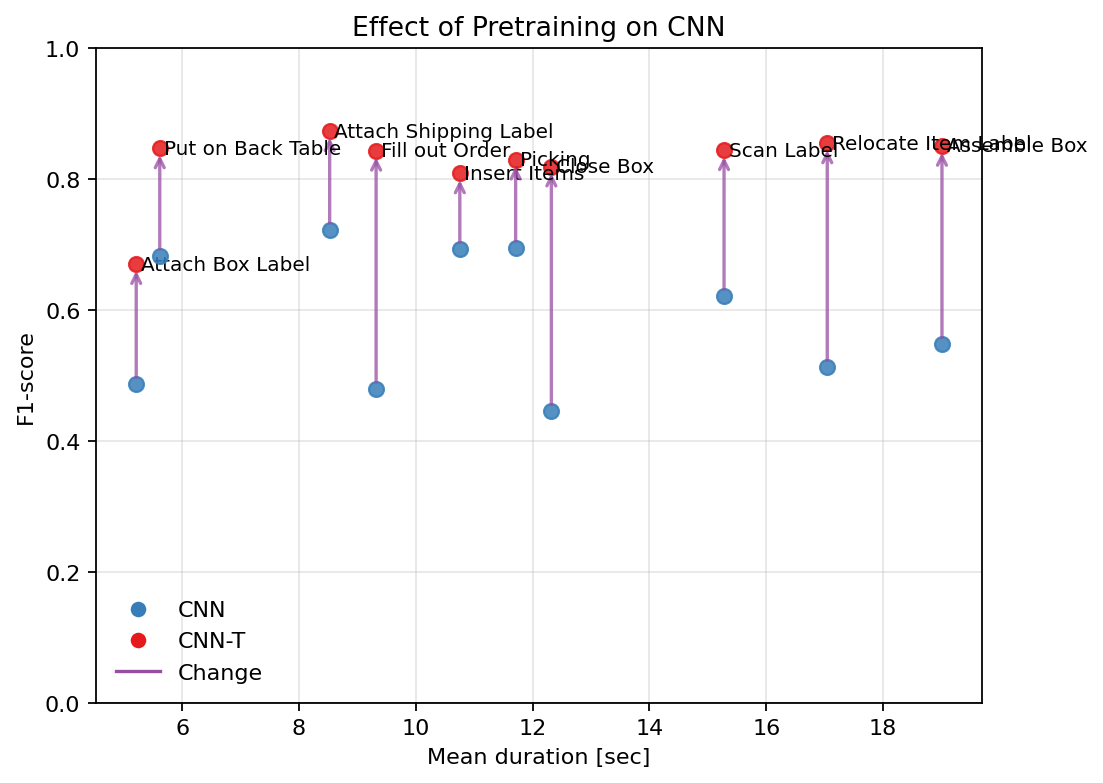

In [256]:
fig = plot_pretrain_arrow_effect(
    df_wide,
    base_col="CNN",
    target_col="CNN-T",
    title="Effect of Pretraining on CNN"
)
plt.show()

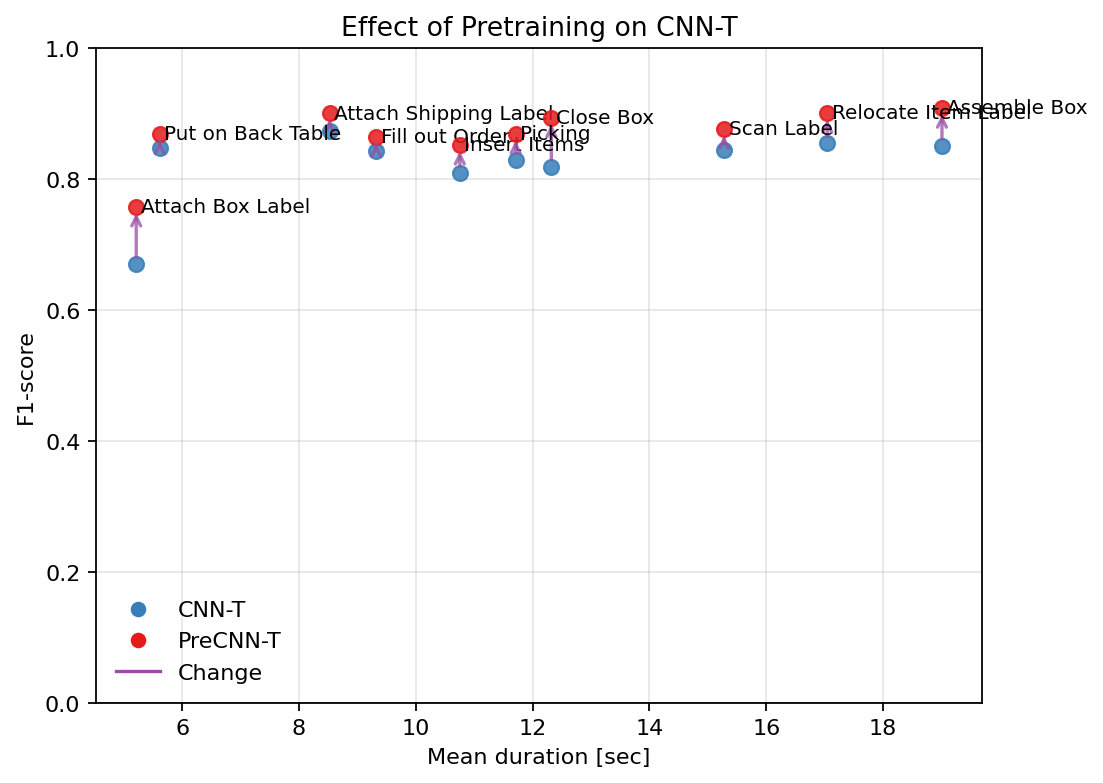

In [257]:
fig = plot_pretrain_arrow_effect(
    df_wide,
    base_col="CNN-T",
    target_col="PreCNN-T",
    title="Effect of Pretraining on CNN-T"
)
plt.show()